# Double Pendulum

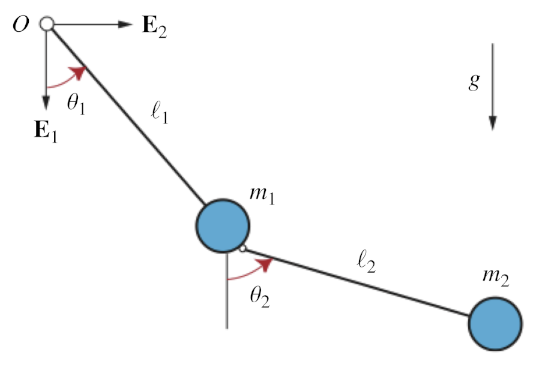

Image credit:
https://www.engineered-mind.com/engineering/double-pendulum-1/

---

Generalised coordinates :
$$
P(\theta_1,\theta_2)
$$
Cartesian coordinates (pendulum 1) :
$$
\begin{cases}
x_1=l_1\sin\theta_1\\
y_1=-l_1\cos\theta_1
\end{cases}
$$
Cartesian coordinates (pendulum 2) :
$$
\begin{cases}
x_2=l_1\sin\theta_1+l_2\sin\theta_2\\
y_2=-(l_1\cos\theta_1+l_2\cos\theta_2)
\end{cases}
$$
---

Newton's Laws :
$$
\begin{align}
(m_1+m_2)l_1\ddot{\theta}_1+m_2l_2\ddot{\theta}_2\cos(\theta_2-\theta_1)&=m_2l_2\dot{\theta}_2^2\sin(\theta_2-\theta_1)-(m_1+m_2)g\sin\theta_1\\
l_2\ddot{\theta}_1+l_1\ddot{\theta}_2\cos(\theta_2-\theta_1)&=-l_1\dot{\theta}_1^2\sin(\theta_2-\theta_1)-g\sin\theta_2
\end{align}
$$
In matrix form :
$$
A\,\vec{\ddot{\theta}}=\vec{b}
$$
$$
\text{where}\quad
\begin{cases}
\begin{align*}
\vec{\ddot{\theta}}&=\begin{bmatrix}
\ddot{\theta}_1\\
\ddot{\theta}_2
\end{bmatrix},\\\\
A &= \begin{bmatrix}
(m_1+m_2)l_1 & m_2l_2\cos(\theta_2-\theta_1) \\
l_2 & l_1\cos(\theta_2-\theta_1)
\end{bmatrix},\\\\
\vec{b} &= \begin{bmatrix}
m_2l_2\dot{\theta}_2^2\sin(\theta_2-\theta_1)-(m_1+m_2)g\sin\theta_1\\
-l_1\dot{\theta}_1^2\sin(\theta_2-\theta_1)-g\sin\theta_2
\end{bmatrix}.
\end{align*}
\end{cases}
$$
---

Converting into system of first order ODEs :

$$
\text{Let}\quad \omega_1=\frac{d\theta_1}{dt}\quad\text{and}\quad \omega_2=\frac{d\theta_2}{dt}
$$

Out state vector and its derivitive is :
$$
y=\begin{pmatrix}
\theta_1 \\
\theta_2 \\
\omega_1 \\
\omega_2
\end{pmatrix}\quad\text{and}\quad
\frac{dy}{dt}=\begin{pmatrix}
\omega_1 \\
\omega_2 \\
\alpha_1 \\
\alpha_2
\end{pmatrix},\quad\text{where}\quad \alpha_1=\frac{d\omega_1}{dt}=\ddot{\theta}_1,\quad\alpha_2=\frac{d\omega_2}{dt}=\ddot{\theta}_2
$$

---

# Helper Functions

In [ ]:
import numpy as np
from scipy.linalg import solve

def position_bob1(θ1, l1):
    """Returns the (x, y) position of the first bob."""
    x1 = l1 * np.sin(θ1)
    y1 = -l1 * np.cos(θ1)
    return x1, y1

def velocity_bob1(θ1, ω1, l1):
    """Returns the (vx, vy) velocity of the first bob."""
    vx1 = l1 * ω1 * np.cos(θ1)
    vy1 = l1 * ω1 * np.sin(θ1)
    return vx1, vy1

def position_bob2(x1, y1, θ2, l2):
    """Returns the (x, y) position of the second bob."""
    x2 = x1 + l2 * np.sin(θ2)
    y2 = y1 - l2 * np.cos(θ2)
    return x2, y2

def velocity_bob2(vx1, vy1, θ2, ω2, l2):
    """Returns the (vx, vy) velocity of the second bob."""
    vx2 = vx1 + l2 * ω2 * np.cos(θ2)
    vy2 = vy1 + l2 * ω2 * np.sin(θ2)
    return vx2, vy2

def double_pendulum_derivatives(t, y, m1, m2, l1, l2, g):
    """
    Returns the derivatives of the double pendulum system.
    """
    # Parameters
    θ1, θ2, ω1, ω2 = y # state vector
    delta = θ2 - θ1
    m12 = m1 + m2
    
    # Defining the vectors as matrix functions
    A = np.array([
        [m12 * l1, m2 * l2 * np.cos(delta)],
        [l1 * np.cos(delta), l2]
    ])
    
    b = np.array([
        m2 * l2 * abs(ω2**2) * np.sin(delta) - m12 * g * np.sin(θ1),
        -l1 * abs(ω1**2) * np.sin(delta) - g * np.sin(θ2)
    ])
    
    # Solve for acceleration
    α1, α2 = solve(A, b)
    
    return np.array([ω1, ω2, α1, α2])

def rk4_step(f, t, y, dt, *args):
    """
    4th Order Runge-Kutta step
    """
    k1 = f(t, y, *args)
    k2 = f(t + dt/2, y + dt/2 * k1, *args)
    k3 = f(t + dt/2, y + dt/2 * k2, *args)
    k4 = f(t + dt, y + dt * k3, *args)

    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [ ]:
def simulate_double_pendulum(θ1, θ2, ω1=0, ω2=0, 
                             t_max=10, dt=0.01, 
                             m1=1, m2=1, 
                             l1=1, l2=1, 
                             g=9.81):
    """
    Simulate the double pendulum
    """
    # Initial state
    y = np.array([θ1, θ2, ω1, ω2])
    
    # Time array
    t_values = np.arange(0, t_max, dt)
    
    # Store results
    results = np.zeros((len(t_values), 4))
    results[0] = y
    
    # Simulation loop
    for i in range(1, len(t_values)):
        # print(i)
        results[i] = rk4_step(double_pendulum_derivatives, t_values[i-1], 
                             results[i-1], dt, m1, m2, l1, l2, g)

    
    return t_values, results

# Results

In [ ]:
import matplotlib.pyplot as plt

# SIMPLE TEST CASE
if __name__ == "__main__":
    print("Simple Double Pendulum Test")
    print("Initial conditions: θ1=π/4, θ2=π/2, both starting from rest")
    
    # Run simulation
    t, results = simulate_double_pendulum(
        θ1=90*np.pi/180, # 90 degrees
        θ2=45*np.pi/180, # 45 degrees  
        ω1=0,            # starting from rest
        ω2=0,            # starting from rest
        t_max=10,        # simulate for 10 seconds
        dt=0.01          # time step of 0.01 seconds
    )
    
    # Extract results
    theta1, theta2, omega1, omega2 = results.T
    
    # Print some basic info
    print(f"Simulation completed!")
    print(f"Time steps: {len(t)}")
    print(f"Final angles: θ1={theta1[-1]:.3f} rad, θ2={theta2[-1]:.3f} rad")
    print(f"Final velocities: ω1={omega1[-1]:.3f} rad/s, ω2={omega2[-1]:.3f} rad/s")
    
    # Simple plot
    plt.figure(figsize=(10, 6))
    plt.plot(t, theta1 * 180 / np.pi, label='θ₁ (first pendulum)')
    plt.plot(t, theta2 * 180 / np.pi, label='θ₂ (second pendulum)')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title('Double Pendulum Motion')
    plt.legend()
    plt.grid(True)
    plt.show()

# Animation

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Cartesian coordinates of bobs
dt = 0.01 
l1 = l2 = m1 = m2 = 1.0
x1, y1 = position_bob1(theta1, l1)
x2, y2 = position_bob2(x1, y1, theta2, l2)


# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = "Liberation Serif"
plt.rcParams['figure.dpi'] = 100

# Create plots
fig, ax = plt.subplots()

# Customize axes
ax.set_title(r"Double Pendulum Simulation")
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axhline(y=0, ls=':', lw=0.5, color='black')
ax.axvline(x=0, ls=':', lw=0.5, color='black')

# Pendulum 1
line1, = ax.plot([], [], c='black', lw=0.5, ls='--')
scat1 = ax.scatter([], [], c='r', s=10, label=f'Pendulum 1')

# Pendulum 2
line2, = ax.plot([], [], c='black', lw=0.5, ls='--')
scat2 = ax.scatter([], [], c='b', s=10, label=f'Pendulum 2')

# Legends
ax.legend(handles=[scat1, scat2], frameon=True)

def update(frame): # For each frame, update the data stored on each artist

    # Line (string)
    line1.set_data([0, x1[frame]], [0, y1[frame]])
    line2.set_data([x1[frame], x2[frame]], [y1[frame], y2[frame]])
    
    # Scatter
    data1 = np.stack([x1[frame], y1[frame]]).T
    data2 = np.stack([x2[frame], y2[frame]]).T
    scat1.set_offsets(data1)
    scat2.set_offsets(data2)

    return (scat1, scat2)

ani = animation.FuncAnimation(fig=fig, func=update, frames=len(x1), interval=dt*1000, blit=True)

# PLay the animation
plt.close() # Hide extra image
HTML(ani.to_jshtml()) # Display inline